In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                     f1_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
import joblib

ЭТАП 1: Анализ данных (EDA)
Общая загрузка


In [ ]:
# 1.	Загрузить train.csv, вывести 10 строк.
df = pd.read_csv('loan_data.csv')
df.head(11)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [ ]:
# 2.	Посмотреть .info() и .shape.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.shape

(45000, 14)

In [ ]:
# 3.Проверить уникальные по object-признакамю
df.select_dtypes(include='object')

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No
...,...,...,...,...,...
44995,male,Associate,RENT,MEDICAL,No
44996,female,Associate,RENT,HOMEIMPROVEMENT,No
44997,male,Associate,RENT,DEBTCONSOLIDATION,No
44998,male,Bachelor,RENT,EDUCATION,No


Pandas-практика


In [ ]:
object_typea_vaiues = ['person_gender', 'person_education','person_home_ownership',
                       'loan_intent', 'previous_loan_defaults_on_file' ]
for i in object_typea_vaiues:
 print(f'{i}:{df[i].unique()}')

person_gender:['female' 'male']
person_education:['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership:['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent:['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file:['No' 'Yes']


In [ ]:
#4.-Оставить только выбранные 7 признаков + целевую переменную.
new_df = df[['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership',
         'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']]

In [ ]:
df


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
#5.Сохранить облегчённый датасет в loan_clean.csv.
df.to_csv('loan_clean.csv', index=False)

In [ ]:

#6.Посчитать средний доход, возраст, стаж.
print("Средний доход:", df['person_income'].mean())
print("Средний возраст:", df['person_age'].mean())
print("Средний стаж:", df['person_emp_exp'].mean())

Средний доход: 80319.05322222222
Средний возраст: 27.76417777777778
Средний стаж: 5.410333333333333


In [ ]:
#7.Сколько заемщиков имеют кредитный балл < 600?
low_score = df[df['credit_score'] < 600].shape[0]
print("Кредитный балл < 600:", low_score)

Кредитный балл < 600: 10828


In [ ]:
#8.Распределение по типу жилья (person_home_ownership) — value_counts().
home_counts = df['person_home_ownership'].value_counts()
print(home_counts)

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64


In [ ]:

#9.Средняя ставка и сумма кредита по группам loan_status.
group_stats = df.groupby('loan_status')[['loan_int_rate','loan_amnt']].mean()
print(group_stats)

             loan_int_rate     loan_amnt
loan_status                             
0                10.477981   9219.576914
1                12.856794  10855.689800


In [ ]:
#10.Кол-во заявителей с опытом работы 0 лет.
ddd = df[df['person_emp_exp'] == 0].shape[0]
print("0 лет стажа:", ddd)

0 лет стажа: 9566


In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
#11. Сколько заемщиков берут кредит более чем на половину дохода
high_loan = (df['loan_int_rate'] > 0.5 ).sum()
print("Кредит > 50% дахода:", high_loan)

Кредит > 50% дахода: 45000


In [ ]:
#12.Группировка по person_home_ownership — средний loan_int_rate.
home_rate = df.groupby('person_home_ownership')['loan_int_rate'].mean()
print(home_rate)

person_home_ownership
MORTGAGE    10.557747
OTHER       12.032991
OWN         10.827231
RENT        11.378069
Name: loan_int_rate, dtype: float64


In [ ]:
#13.	Hist / distplot по:
#o	person_income
#o	credit_score
#o	loan_int_rate

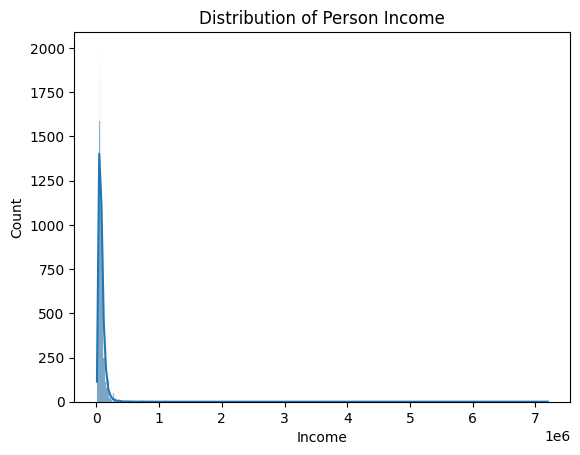

In [ ]:
sns.histplot(df['person_income'], kde=True)
plt.title("Distribution of Person Income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

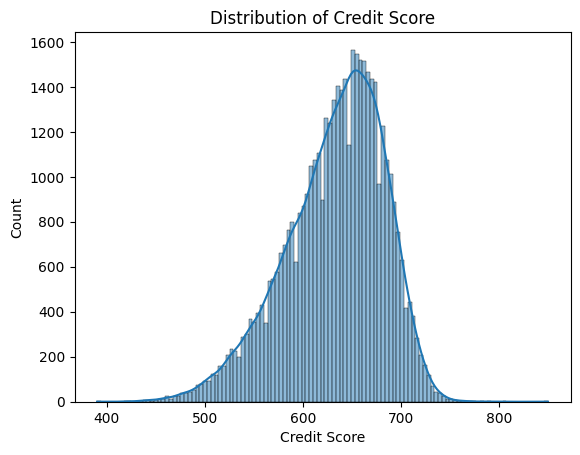

In [ ]:
sns.histplot(df['credit_score'], kde=True)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

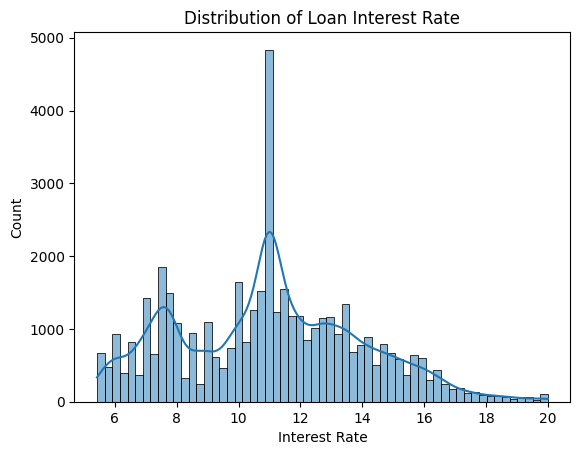

In [ ]:
sns.histplot(df['loan_int_rate'], kde=True)
plt.title("Distribution of Loan Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Count")
plt.show()

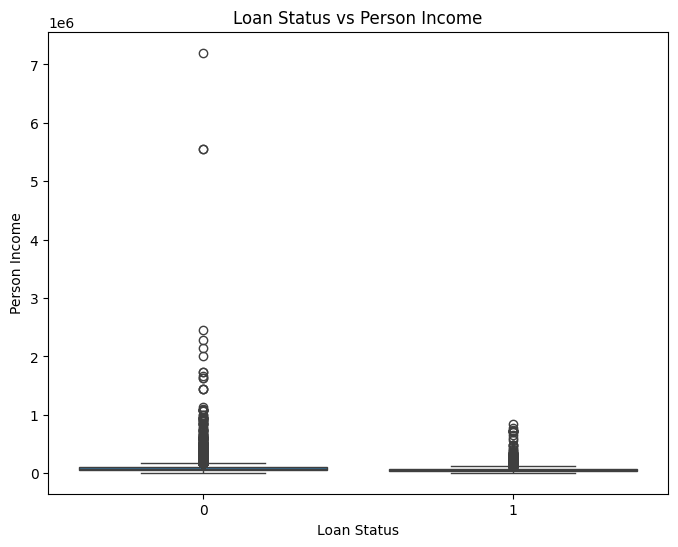

In [ ]:
#14.Boxplot: loan_status vs person_income
plt.figure(figsize=(8,6))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title("Loan Status vs Person Income")
plt.xlabel("Loan Status")
plt.ylabel("Person Income")
plt.show()

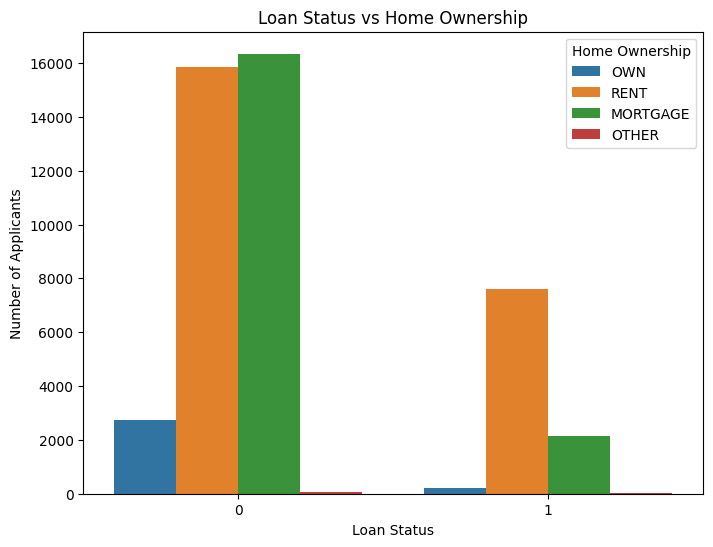

In [ ]:
#15.Barplot: loan_status vs person_home_ownership
plt.figure(figsize=(8,6))
sns.countplot(x='loan_status', hue='person_home_ownership', data=df)
plt.title("Loan Status vs Home Ownership")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.legend(title='Home Ownership')
plt.show()

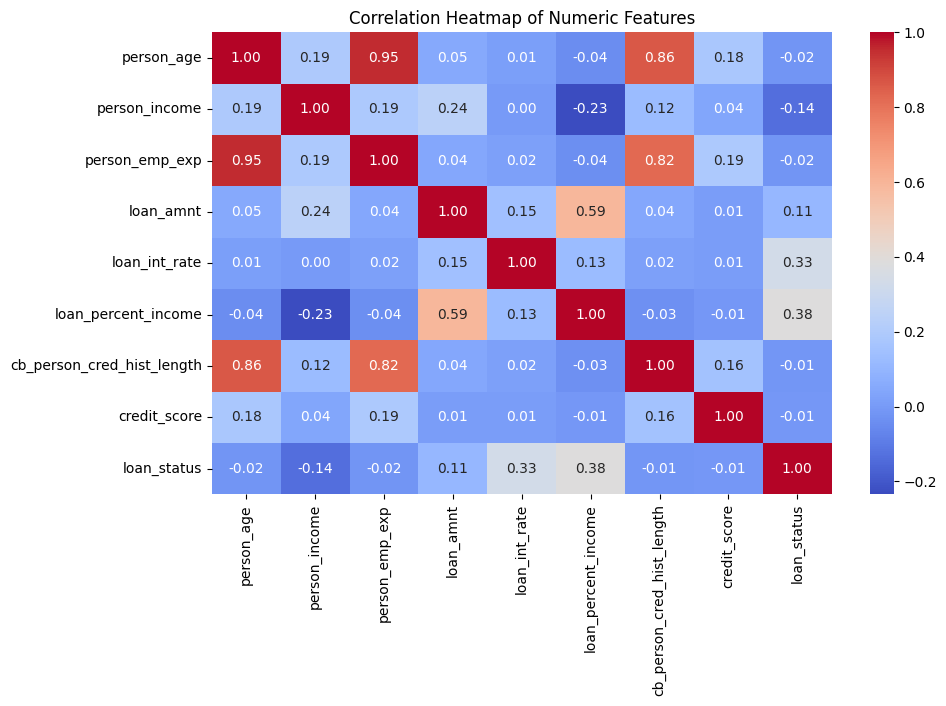

In [ ]:
#16.Heatmap корреляций числовых признаков
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

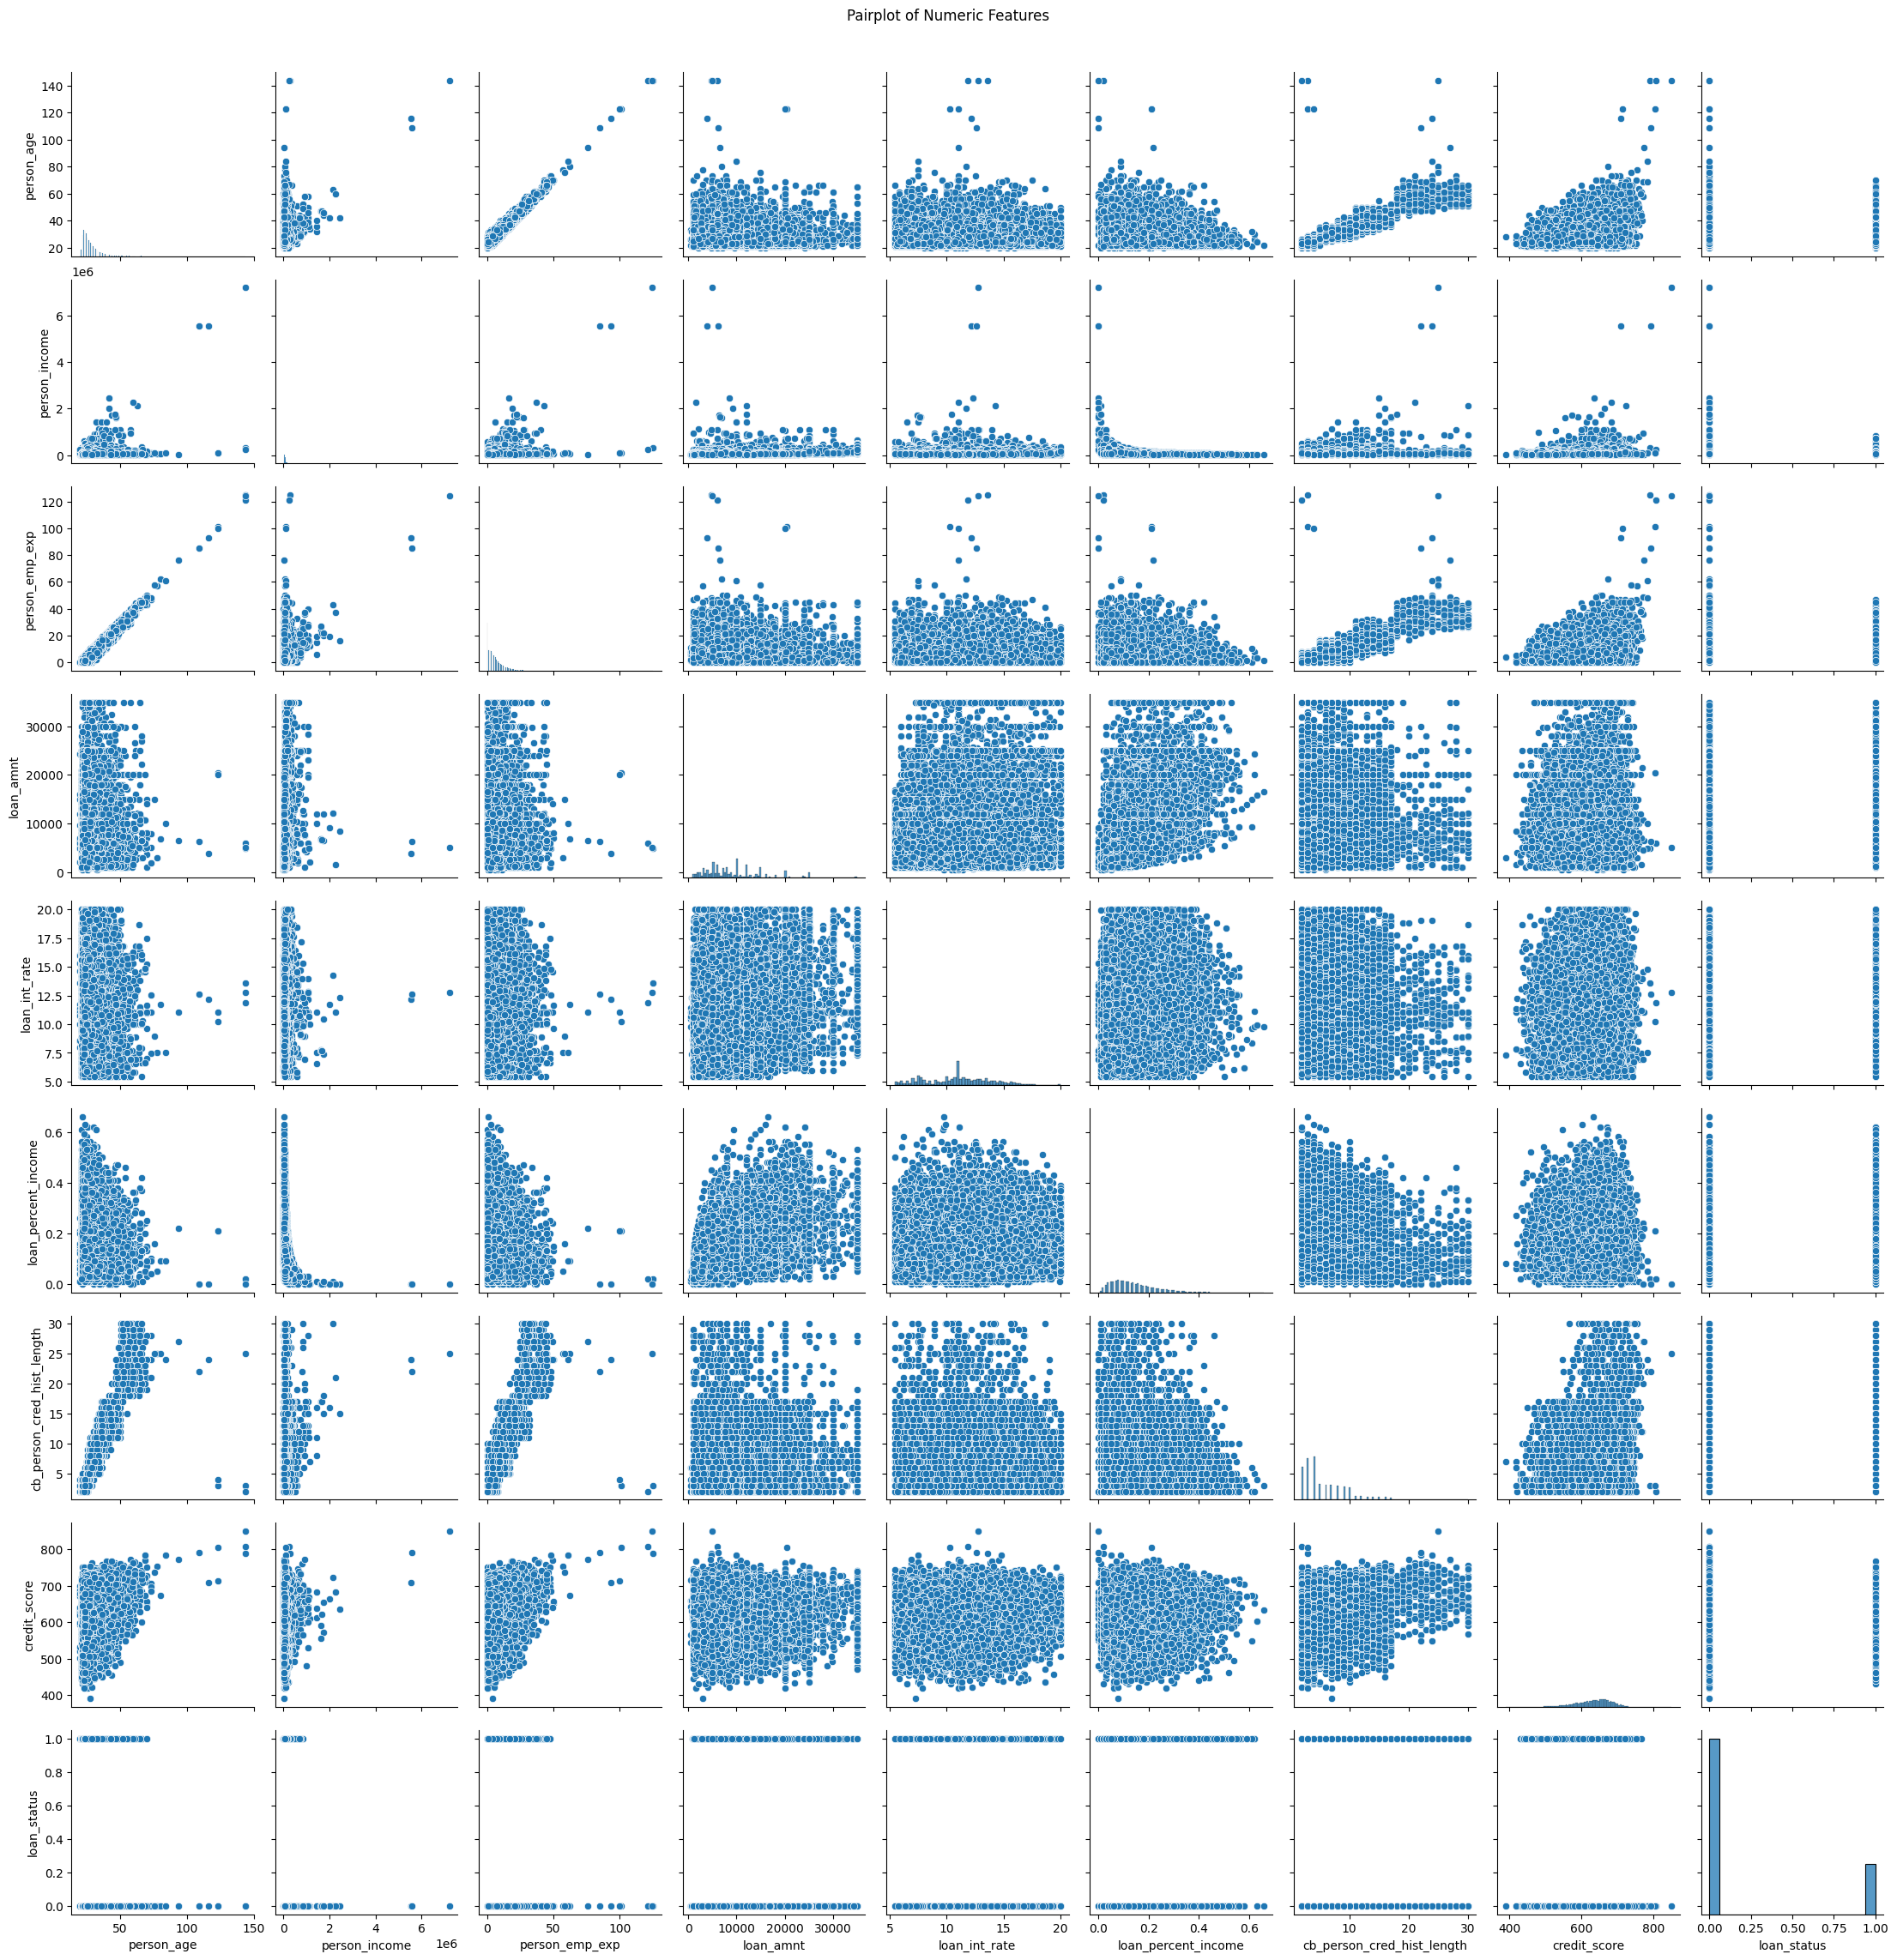

In [ ]:
#17.Pairplot по числовым признакам
numeric_cols = df.select_dtypes(include='number')
sns.pairplot(numeric_cols)
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

In [ ]:
#18.Проверка пропущенных значений и заполнение (или удаление).
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
#19.	Кодировка категориальных признаков (OneHotEncoder или LabelEncoder):
#o	person_home_ownership
df = pd.get_dummies(df, columns=['person_home_ownership','person_gender',
                                 'person_education','previous_loan_defaults_on_file','loan_intent'],
                    drop_first=True, dtype=int)

In [ ]:
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_home_ownership_OTHER,...,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,previous_loan_defaults_on_file_Yes,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,0,0,0,1,0,0,0,0,1,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,1,0,0,0,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,1,0,0,0,0,1,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,1,0,0,0,0,0,0,1,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,0,...,0,0,0,0,0,0,0,1,0,0
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,0,...,0,0,0,0,0,0,1,0,0,0
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,0,...,0,0,0,0,0,0,0,0,0,0
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,0,...,1,0,0,0,0,1,0,0,0,0


In [ ]:
#20.Масштабирование числовых признаков (StandardScaler).
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns='loan_status'))

In [ ]:
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_home_ownership_OTHER,...,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,previous_loan_defaults_on_file_Yes,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,0,0,0,1,0,0,0,0,1,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,1,0,0,0,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,1,0,0,0,0,1,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,1,0,0,0,0,0,0,1,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,0,...,0,0,0,0,0,0,0,1,0,0
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,0,...,0,0,0,0,0,0,1,0,0,0
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,0,...,0,0,0,0,0,0,0,0,0,0
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,0,...,1,0,0,0,0,1,0,0,0,0


In [ ]:
scaled_data

array([[-0.95353824, -0.10408961, -0.89228413, ..., -0.48425217,
         2.22681082, -0.45857996],
       [-1.11896309, -0.84600467, -0.89228413, ..., -0.48425217,
        -0.44907272, -0.45857996],
       [-0.45726369, -0.84406489, -0.3975175 , ...,  2.06503979,
        -0.44907272, -0.45857996],
       ...,
       [ 0.8661351 , -0.29068126,  0.26217134, ..., -0.48425217,
        -0.44907272, -0.45857996],
       [ 0.2044357 , -0.58634807, -0.23259529, ..., -0.48425217,
        -0.44907272, -0.45857996],
       [-0.62268854, -0.35699428, -0.72736192, ..., -0.48425217,
        -0.44907272, -0.45857996]])

In [ ]:
#21.Разделение X и y (где y = loan_status).
x= scaled_data
y=df['loan_status']

In [ ]:
#22.train/test split (80/20).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ЭТАП 3: Логистическая регрессия

In [ ]:
#23.Обучить LogisticRegression() на обучающей выборке.
log_model = LogisticRegression()
log_model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
#24.Предсказать на тестовой выборке.
pred = log_model.predict(x_test)

In [ ]:
# 25.Посчитать метрики:
# Accuracy
# Precision, Recall
# F1-score
# Confusion Matrix (график)
# ROC AUC (и построить кривую)
print(accuracy_score(pred, y_test))
print(f1_score(pred, y_test))

0.8945555555555555
0.7589535179070358


In [ ]:
#26.Вывести коэффициенты модели (model.coef_, model.intercept_)
log_model.coef_

array([[ 1.74895352e-01,  4.15290744e-02, -1.55590033e-01,
        -6.35496399e-01,  1.00103590e+00,  1.39199070e+00,
        -1.41329348e-02, -4.46953726e-01,  1.92756320e-02,
        -3.74846918e-01,  3.54392948e-01,  1.37185356e-02,
        -1.79331696e-02, -1.37996927e-02,  3.07946465e-03,
        -1.62475328e-03, -4.49058867e+00, -3.44304467e-01,
        -2.82265895e-03, -1.05642272e-01, -2.60741573e-01,
        -4.59887738e-01]])

In [ ]:
# 27.Сохранить модель (joblib или pickle).
joblib.dump(log_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']